# Customer Sales Analysis

## Project Overview
This project analyzes customer sales data using Python and pandas. The goal is to clean and validate the dataset, analyze sales and profitability, identify customer and product trends, and develop data-driven business recommendations.

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("Customer_Sales_Python_Portfolio.csv")

In [4]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Segment,Region,State,Sales_Channel,Category,Product,Sales,Quantity,Discount,Cost,Profit
0,ORD-10186,12/13/2025,CUST-0099,Ethan Clark,Consumer,South,FL,Online,Furniture,Filing Cabinet,1426.75,6,0.25,1017.20,409.55
1,ORD-10519,07/29/2025,CUST-0105,Ava Wilson,Corporate,South,GA,Online,Furniture,Conference Table,1396.49,4,0.10,1154.03,242.46
2,ORD-10249,06/08/2025,CUST-0174,Chloe Lee,Home Office,East,PA,Online,Furniture,Bookcase,1073.02,4,0.20,782.18,290.84
3,ORD-10006,09/11/2025,CUST-0189,Noah Martinez,Consumer,South,SC,Partner,Office Supplies,Binder Set,37.29,1,0.10,25.09,12.20
4,ORD-10776,01/24/2025,CUST-0210,Carlos Thomas,consumer,West,CO,Online,Office Supplies,Printer Paper,102.37,2,0.00,60.87,41.50


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       862 non-null    str    
 1   Order_Date     862 non-null    str    
 2   Customer_ID    862 non-null    str    
 3   Customer_Name  848 non-null    str    
 4   Segment        862 non-null    str    
 5   Region         854 non-null    str    
 6   State          862 non-null    str    
 7   Sales_Channel  862 non-null    str    
 8   Category       862 non-null    str    
 9   Product        862 non-null    str    
 10  Sales          852 non-null    float64
 11  Quantity       862 non-null    int64  
 12  Discount       862 non-null    float64
 13  Cost           862 non-null    float64
 14  Profit         862 non-null    float64
dtypes: float64(4), int64(1), str(10)
memory usage: 170.7 KB


In [6]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name    14
Segment           0
Region            8
State             0
Sales_Channel     0
Category          0
Product           0
Sales            10
Quantity          0
Discount          0
Cost              0
Profit            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(12)

In [8]:
df["Segment"].value_counts()

Segment
Consumer       476
Corporate      231
Home Office    137
consumer         6
CORPORATE        6
Home office      6
Name: count, dtype: int64

In [9]:
df["Sales_Channel"].value_counts()

Sales_Channel
Online       407
Retail       326
Partner      114
online         5
 partner       5
RETAIL         5
Name: count, dtype: int64

In [10]:
df["Category"].value_counts()

Category
Technology         334
Office Supplies    272
Furniture          256
Name: count, dtype: int64

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(850, 15)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [15]:
df["Order_Date"].dtype

dtype('<M8[us]')

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 850 entries, 0 to 861
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       850 non-null    str           
 1   Order_Date     850 non-null    datetime64[us]
 2   Customer_ID    850 non-null    str           
 3   Customer_Name  836 non-null    str           
 4   Segment        850 non-null    str           
 5   Region         842 non-null    str           
 6   State          850 non-null    str           
 7   Sales_Channel  850 non-null    str           
 8   Category       850 non-null    str           
 9   Product        850 non-null    str           
 10  Sales          840 non-null    float64       
 11  Quantity       850 non-null    int64         
 12  Discount       850 non-null    float64       
 13  Cost           850 non-null    float64       
 14  Profit         850 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64

In [17]:
df[df["Customer_Name"].isnull()]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Segment,Region,State,Sales_Channel,Category,Product,Sales,Quantity,Discount,Cost,Profit
81,ORD-10273,2025-05-16,CUST-0034,NaN,Consumer,South,SC,Online,Furniture,Conference Table,740.57,3,0.20,552.08,188.49
130,ORD-10174,2025-05-21,CUST-0159,NaN,Consumer,South,SC,Online,Technology,Headset,32.54,1,0.15,18.70,13.84
163,ORD-10466,2025-08-30,CUST-0213,NaN,Consumer,West,OR,Online,Furniture,Bookcase,1663.12,7,0.25,1345.40,317.72
402,ORD-10814,2025-09-20,CUST-0063,NaN,Corporate,West,OR,Online,Furniture,Conference Table,1809.06,6,0.10,1276.34,532.72
493,ORD-10027,2025-10-02,CUST-0089,NaN,Corporate,South,SC,Online,Furniture,Office Chair,2043.78,7,0.00,1605.32,438.46
502,ORD-10267,2025-06-19,CUST-0099,NaN,Home Office,East,PA,Online,Furniture,Office Chair,2056.68,6,0.00,1429.88,626.80
503,ORD-10144,2025-09-24,CUST-0090,NaN,Consumer,South,FL,Partner,Office Supplies,Pens,149.82,3,0.00,93.80,56.02
534,ORD-10261,2025-04-18,CUST-0175,NaN,Home Office,South,SC,Retail,Office Supplies,Binder Set,76.51,3,0.30,43.34,33.17
628,ORD-10752,2025-08-13,CUST-0033,NaN,Corporate,West,WA,RETAIL,Technology,Monitor,451.79,2,0.25,313.63,138.16
650,ORD-10837,2025-04-17,CUST-0178,NaN,Consumer,East,NY,Online,Technology,Webcam,667.27,3,0.25,380.27,287.00


In [18]:
df[df["Customer_ID"] == "CUST-0033"]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Segment,Region,State,Sales_Channel,Category,Product,Sales,Quantity,Discount,Cost,Profit
328,ORD-10522,2025-07-27,CUST-0033,Emma Martinez,Corporate,East,VA,Partner,Technology,Headset,789.99,3,0.00,514.37,275.62
428,ORD-10457,2025-08-18,CUST-0033,Emma Martinez,Consumer,South,SC,Partner,Technology,Webcam,1092.60,3,0.00,816.63,275.97
628,ORD-10752,2025-08-13,CUST-0033,NaN,Corporate,West,WA,RETAIL,Technology,Monitor,451.79,2,0.25,313.63,138.16


In [20]:
name_counts = df.groupby("Customer_ID")["Customer_Name"].nunique()

In [21]:
name_counts[name_counts > 1]

Series([], Name: Customer_Name, dtype: int64)

In [22]:
name_counts[name_counts == 0]

Series([], Name: Customer_Name, dtype: int64)

In [24]:
df["Customer_Name"] = df.groupby("Customer_ID")["Customer_Name"].transform(lambda x: x.fillna(x.mode()[0]))

In [25]:
df[df["Customer_Name"].isnull()]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Segment,Region,State,Sales_Channel,Category,Product,Sales,Quantity,Discount,Cost,Profit


In [26]:
df["Customer_Name"].isnull().sum()

np.int64(0)

In [27]:
df[df["Region"].isnull()]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Segment,Region,State,Sales_Channel,Category,Product,Sales,Quantity,Discount,Cost,Profit
125,ORD-10068,2025-10-14,CUST-0082,Noah Johnson,Corporate,NaN,SC,Online,Technology,Laptop Dock,1245.06,4,0.00,880.45,364.61
250,ORD-10594,2025-06-03,CUST-0216,Lena Brown,Corporate,NaN,TN,Partner,Office Supplies,Binder Set,NaN,5,0.00,138.04,98.18
274,ORD-10583,2025-11-17,CUST-0024,Diego Wilson,Home Office,NaN,GA,Online,Office Supplies,Labels,26.97,1,0.20,18.70,8.27
304,ORD-10181,2025-12-03,CUST-0207,Chloe Davis,Home Office,NaN,VA,Retail,Technology,Wireless Mouse,266.18,1,0.10,181.86,84.32
388,ORD-10495,2025-07-18,CUST-0064,Sophia Taylor,Consumer,NaN,MD,Online,Technology,Webcam,613.16,3,0.20,451.74,161.42
546,ORD-10810,2025-11-30,CUST-0220,Ethan Moore,Corporate,NaN,CO,Retail,Furniture,Standing Desk,1286.54,6,0.25,1033.96,252.58
712,ORD-10242,2025-12-07,CUST-0129,Carlos Wilson,Consumer,NaN,OH,Retail,Technology,Headset,367.22,1,0.10,230.40,136.82
801,ORD-10146,2025-05-10,CUST-0188,Maya Wilson,Consumer,NaN,NJ,Online,Office Supplies,Binder Set,205.68,7,0.30,125.66,80.02


In [28]:
df.groupby("State")["Region"].nunique()

State
AZ    1
CA    1
CO    1
FL    1
GA    1
IL    1
MD    1
MI    1
MO    1
NC    1
NJ    1
NY    1
OH    1
OR    1
PA    1
SC    1
TN    1
TX    1
VA    1
WA    1
Name: Region, dtype: int64

In [29]:
df["Region"] = df.groupby("State")["Region"].transform(lambda x: x.fillna(x.mode()[0]))

In [30]:
df["Region"].isnull().sum()

np.int64(0)

In [31]:
df[df["Sales"].isnull()]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Segment,Region,State,Sales_Channel,Category,Product,Sales,Quantity,Discount,Cost,Profit
210,ORD-10641,2025-05-15,CUST-0148,Chloe Taylor,Corporate,South,NC,Online,Technology,Webcam,NaN,3,0.00,500.54,238.72
218,ORD-10411,2025-09-29,CUST-0039,Lena Martinez,Corporate,Central,MI,RETAIL,Technology,Wireless Mouse,NaN,4,0.10,681.33,279.43
228,ORD-10182,2025-12-07,CUST-0034,Lena Wilson,Corporate,Central,OH,Online,Technology,Headset,NaN,5,0.10,814.04,450.08
232,ORD-10792,2025-04-20,CUST-0100,Zoe Moore,Home Office,Central,MO,Online,Furniture,Standing Desk,NaN,4,0.10,820.74,175.32
250,ORD-10594,2025-06-03,CUST-0216,Lena Brown,Corporate,South,TN,Partner,Office Supplies,Binder Set,NaN,5,0.00,138.04,98.18
577,ORD-10733,2025-05-07,CUST-0203,Noah Smith,Corporate,East,NJ,Retail,Technology,Monitor,NaN,6,0.10,870.49,497.61
707,ORD-10011,2025-03-28,CUST-0116,Sophia Brown,Corporate,East,NY,Partner,Office Supplies,Desk Organizer,NaN,4,0.00,109.60,69.37
754,ORD-10656,2025-01-06,CUST-0118,Emma Clark,Consumer,East,NJ,Online,Furniture,Filing Cabinet,NaN,4,0.15,618.86,114.53
757,ORD-10725,2025-03-05,CUST-0173,Diego Thomas,Corporate,East,NJ,Online,Office Supplies,Desk Organizer,NaN,7,0.10,189.75,145.04
805,ORD-10054,2025-08-24,CUST-0103,Noah Garcia,Corporate,South,SC,Online,Furniture,Filing Cabinet,NaN,7,0.30,1299.24,230.88


In [32]:
df["Sales_Check"] = df["Profit"] + df["Cost"]

In [33]:
df[["Sales", "Cost", "Profit", "Sales_Check"]].head()

,Sales,Cost,Profit,Sales_Check
0,1426.75,1017.20,409.55,1426.75
1,1396.49,1154.03,242.46,1396.49
2,1073.02,782.18,290.84,1073.02
3,37.29,25.09,12.20,37.29
4,102.37,60.87,41.50,102.37


In [34]:
(df["Sales"].round(2) == df["Sales_Check"].round(2)).value_counts()

True     840
False     10
Name: count, dtype: int64

In [35]:
df[df["Sales"].isnull()][["Sales", "Cost", "Profit", "Sales_Check"]]

,Sales,Cost,Profit,Sales_Check
210,NaN,500.54,238.72,739.26
218,NaN,681.33,279.43,960.76
228,NaN,814.04,450.08,1264.12
232,NaN,820.74,175.32,996.06
250,NaN,138.04,98.18,236.22
577,NaN,870.49,497.61,1368.10
707,NaN,109.60,69.37,178.97
754,NaN,618.86,114.53,733.39
757,NaN,189.75,145.04,334.79
805,NaN,1299.24,230.88,1530.12


In [36]:
df["Sales"] = df["Sales"].fillna(df["Cost"] + df["Profit"])

In [37]:
df["Sales"].isnull().sum()

np.int64(0)

In [38]:
df = df.drop(columns=["Sales_Check"])

In [39]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Segment          0
Region           0
State            0
Sales_Channel    0
Category         0
Product          0
Sales            0
Quantity         0
Discount         0
Cost             0
Profit           0
dtype: int64

In [40]:
df["Segment"] = df["Segment"].str.strip().str.title()

In [41]:
df["Segment"].value_counts()

Segment
Consumer       474
Corporate      234
Home Office    142
Name: count, dtype: int64

In [42]:
df["Sales_Channel"] = df["Sales_Channel"].str.strip().str.title()

In [43]:
df["Sales_Channel"].value_counts()

Sales_Channel
Online     405
Retail     326
Partner    119
Name: count, dtype: int64

In [44]:
df.shape

(850, 15)

In [45]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Segment          0
Region           0
State            0
Sales_Channel    0
Category         0
Product          0
Sales            0
Quantity         0
Discount         0
Cost             0
Profit           0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis

In [48]:
df.describe()

,Order_Date,Sales,Quantity,Discount,Cost,Profit
count,850,850.000000,850.000000,850.000000,850.000000,850.000000
mean,2025-06-30 16:49:41.647058,728.264153,4.055294,0.115353,514.356835,213.907318
min,2025-01-01 00:00:00,12.000000,1.000000,0.000000,8.130000,2.130000
25%,2025-03-30 00:00:00,211.632500,2.000000,0.000000,138.915000,66.562500
50%,2025-07-03 12:00:00,556.735000,4.000000,0.100000,383.650000,160.865000
75%,2025-09-30 18:00:00,1191.330000,6.000000,0.200000,836.955000,326.727500
max,2025-12-31 00:00:00,2514.820000,7.000000,0.300000,1918.490000,831.420000
std,NaN,584.305941,1.990082,0.096598,431.658843,175.795331


In [49]:
df["Sales"].sum()

np.float64(619024.53)

In [50]:
df["Profit"].sum()

np.float64(181821.22)

In [51]:
profit_margin = (df["Profit"].sum() / df["Sales"].sum()) * 100
profit_margin

np.float64(29.372215669708595)

In [52]:
df["Order_ID"].nunique()

850

In [53]:
average_order_value = df["Sales"].sum() / df["Order_ID"].nunique()

average_order_value

np.float64(728.2641529411765)

In [54]:
df.groupby("Category")["Sales"].sum()

Category
Furniture          272660.69
Office Supplies     46183.37
Technology         300180.47
Name: Sales, dtype: float64

In [55]:
df.groupby("Category")["Profit"].sum()

Category
Furniture           64868.09
Office Supplies     15881.30
Technology         101071.83
Name: Profit, dtype: float64

In [56]:
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum()

category_summary

,Sales,Profit
Category,,
Furniture,272660.69,64868.09
Office Supplies,46183.37,15881.30
Technology,300180.47,101071.83


In [57]:
category_summary["Profit_Margin"] = (category_summary["Profit"] / category_summary["Sales"]) * 100

In [58]:
category_summary

,Sales,Profit,Profit_Margin
Category,,,
Furniture,272660.69,64868.09,23.790775
Office Supplies,46183.37,15881.30,34.387486
Technology,300180.47,101071.83,33.670355


In [59]:
category_summary.sort_values(by="Sales", ascending=False)

,Sales,Profit,Profit_Margin
Category,,,
Technology,300180.47,101071.83,33.670355
Furniture,272660.69,64868.09,23.790775
Office Supplies,46183.37,15881.30,34.387486


In [61]:
df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

Product
Wireless Mouse      79609.44
Filing Cabinet      62321.46
Headset             60965.73
Office Chair        58586.73
Webcam              54993.63
Laptop Dock         54436.35
Conference Table    53857.62
Standing Desk       51747.86
Monitor             50175.32
Bookcase            46147.02
Labels              10270.97
Desk Organizer       9424.18
Pens                 9410.45
Binder Set           8676.16
Printer Paper        8401.61
Name: Sales, dtype: float64

In [62]:
df.groupby("Product")["Profit"].sum().sort_values(ascending=False).head(5)

Product
Wireless Mouse    26587.10
Headset           20901.66
Webcam            19138.15
Laptop Dock       18050.87
Monitor           16394.05
Name: Profit, dtype: float64

In [63]:
product_summary = df.groupby("Product")[["Sales", "Profit"]].sum()

In [64]:
product_summary["Profit_Margin"] = (product_summary["Profit"] / product_summary["Sales"]) * 100

In [65]:
product_summary.sort_values(by="Profit_Margin", ascending=False)

,Sales,Profit,Profit_Margin
Product,,,
Labels,10270.97,3631.34,35.355375
Pens,9410.45,3280.79,34.863264
Webcam,54993.63,19138.15,34.800667
Binder Set,8676.16,3002.51,34.606439
Headset,60965.73,20901.66,34.284277
Desk Organizer,9424.18,3214.27,34.106628
Wireless Mouse,79609.44,26587.10,33.396919
Laptop Dock,54436.35,18050.87,33.159589
Printer Paper,8401.61,2752.39,32.760269


In [66]:
product_summary.sort_values(by="Profit_Margin", ascending=True).head(5)

,Sales,Profit,Profit_Margin
Product,,,
Filing Cabinet,62321.46,14049.33,22.543326
Conference Table,53857.62,12421.73,23.064016
Bookcase,46147.02,10783.99,23.368768
Office Chair,58586.73,14394.09,24.568857
Standing Desk,51747.86,13218.95,25.544921


In [67]:
df.groupby("Product")["Discount"].mean().sort_values(ascending=False)

Product
Laptop Dock         0.142241
Labels              0.135714
Webcam              0.131538
Filing Cabinet      0.123214
Standing Desk       0.119149
Wireless Mouse      0.116875
Conference Table    0.114423
Printer Paper       0.113043
Headset             0.111111
Monitor             0.108491
Binder Set          0.106731
Pens                0.104630
Office Chair        0.100909
Bookcase            0.096429
Desk Organizer      0.093636
Name: Discount, dtype: float64

In [68]:
product_summary["Average_Discount"] = (df.groupby("Product")["Discount"].mean() * 100)

In [71]:
product_summary.sort_values(by="Profit_Margin", ascending=True).head(5)

,Sales,Profit,Profit_Margin,Average_Discount
Product,,,,
Filing Cabinet,62321.46,14049.33,22.543326,12.321429
Conference Table,53857.62,12421.73,23.064016,11.442308
Bookcase,46147.02,10783.99,23.368768,9.642857
Office Chair,58586.73,14394.09,24.568857,10.090909
Standing Desk,51747.86,13218.95,25.544921,11.914894


In [72]:
product_summary["Average_Discount"].corr(product_summary["Profit_Margin"])

np.float64(0.19563429669609736)

In [73]:
df["Discount"].value_counts().sort_index()

Discount
0.00    227
0.05     99
0.10    166
0.15     97
0.20    129
0.25     69
0.30     63
Name: count, dtype: int64

In [74]:
discount_summary = df.groupby("Discount")[["Sales", "Profit"]].sum()

In [75]:
discount_summary["Profit_Margin"] = (discount_summary["Profit"] / discount_summary["Sales"]) * 100

In [76]:
discount_summary

,Sales,Profit,Profit_Margin
Discount,,,
0.00,175310.94,53022.50,30.244832
0.05,76868.49,20767.13,27.016441
0.10,132599.79,39593.92,29.859715
0.15,69142.40,20137.04,29.124011
0.20,84427.35,24864.50,29.450764
0.25,47229.19,13139.40,27.820507
0.30,33446.37,10296.73,30.785792


In [77]:
df.groupby("Segment")["Sales"].sum()

Segment
Consumer       338884.44
Corporate      175973.57
Home Office    104166.52
Name: Sales, dtype: float64

In [78]:
df.groupby("Segment")["Profit"].sum()

Segment
Consumer       99631.02
Corporate      51043.14
Home Office    31147.06
Name: Profit, dtype: float64

In [79]:
segment_summary = df.groupby("Segment")[["Sales", "Profit"]].sum()

In [80]:
segment_summary["Profit_Margin"] = (segment_summary["Profit"] / segment_summary["Sales"]) * 100

In [81]:
segment_summary

,Sales,Profit,Profit_Margin
Segment,,,
Consumer,338884.44,99631.02,29.399703
Corporate,175973.57,51043.14,29.006140
Home Office,104166.52,31147.06,29.901220


In [82]:
df.groupby("Region")["Sales"].sum()

Region
Central    125409.64
East       165109.45
South      182009.26
West       146496.18
Name: Sales, dtype: float64

In [83]:
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum()
region_summary["Profit_Margin"] = (region_summary["Profit"] / region_summary["Sales"]) * 100
region_summary

,Sales,Profit,Profit_Margin
Region,,,
Central,125409.64,37133.73,29.609949
East,165109.45,48138.90,29.155751
South,182009.26,53578.44,29.437206
West,146496.18,42970.15,29.331925


In [84]:
channel_summary = df.groupby("Sales_Channel")[["Sales", "Profit"]].sum()

In [85]:
channel_summary["Profit_Margin"] = (channel_summary["Profit"] / channel_summary["Sales"]) * 100
channel_summary

,Sales,Profit,Profit_Margin
Sales_Channel,,,
Online,308542.71,89381.06,28.968780
Partner,77948.75,23288.06,29.876117
Retail,232533.07,69152.10,29.738609


In [86]:
customer_summary = df.groupby(["Customer_ID", "Customer_Name"])[["Sales", "Profit"]].sum()
customer_summary.head()

,,Sales,Profit
Customer_ID,Customer_Name,,
CUST-0002,Ethan Johnson,5314.61,1565.55
CUST-0003,Andre Thomas,1818.36,651.67
CUST-0004,Malik Taylor,3600.02,802.37
CUST-0005,Diego Brown,5009.23,1329.01
CUST-0006,Marcus Wilson,3110.13,860.29


In [87]:
customer_summary.sort_values(by="Sales", ascending=False).head(10)

,,Sales,Profit
Customer_ID,Customer_Name,,
CUST-0031,Maya Martinez,10129.92,2545.86
CUST-0070,Maya Lee,8323.32,1963.44
CUST-0096,Emma Davis,7936.48,2248.06
CUST-0010,Diego Martinez,7649.67,2218.42
CUST-0169,Andre Davis,7347.61,1927.06
CUST-0203,Noah Smith,7054.31,1860.52
CUST-0182,Emma Taylor,6815.66,1330.61
CUST-0172,Malik Martinez,6650.52,1684.47
CUST-0055,Maya Thomas,6621.84,1738.20


In [88]:
customer_summary.sort_values(by="Profit", ascending=False).head(10)

,,Sales,Profit
Customer_ID,Customer_Name,,
CUST-0031,Maya Martinez,10129.92,2545.86
CUST-0096,Emma Davis,7936.48,2248.06
CUST-0010,Diego Martinez,7649.67,2218.42
CUST-0163,Maya Martinez,5703.70,2131.18
CUST-0026,Carlos Wilson,6100.41,2086.28
CUST-0120,Sophia Brown,6010.14,2075.16
CUST-0053,Lena Brown,6075.08,2047.45
CUST-0197,Andre Wilson,6604.72,1977.74
CUST-0070,Maya Lee,8323.32,1963.44


In [89]:
customer_summary["Profit_Margin"] = (
    customer_summary["Profit"] / customer_summary["Sales"]
) * 100

In [90]:
customer_summary.sort_values(by="Profit", ascending=False).head(10)

,,Sales,Profit,Profit_Margin
Customer_ID,Customer_Name,,,
CUST-0031,Maya Martinez,10129.92,2545.86,25.132084
CUST-0096,Emma Davis,7936.48,2248.06,28.325656
CUST-0010,Diego Martinez,7649.67,2218.42,29.000205
CUST-0163,Maya Martinez,5703.70,2131.18,37.364868
CUST-0026,Carlos Wilson,6100.41,2086.28,34.199013
CUST-0120,Sophia Brown,6010.14,2075.16,34.527648
CUST-0053,Lena Brown,6075.08,2047.45,33.702437
CUST-0197,Andre Wilson,6604.72,1977.74,29.944343
CUST-0070,Maya Lee,8323.32,1963.44,23.589625


In [91]:
customer_summary["Order_Count"] = df.groupby(["Customer_ID", "Customer_Name"])["Order_ID"].nunique()
customer_summary.sort_values(by="Profit", ascending=False).head(10)

,,Sales,Profit,Profit_Margin,Order_Count
Customer_ID,Customer_Name,,,,
CUST-0031,Maya Martinez,10129.92,2545.86,25.132084,10
CUST-0096,Emma Davis,7936.48,2248.06,28.325656,10
CUST-0010,Diego Martinez,7649.67,2218.42,29.000205,7
CUST-0163,Maya Martinez,5703.70,2131.18,37.364868,9
CUST-0026,Carlos Wilson,6100.41,2086.28,34.199013,6
CUST-0120,Sophia Brown,6010.14,2075.16,34.527648,6
CUST-0053,Lena Brown,6075.08,2047.45,33.702437,7
CUST-0197,Andre Wilson,6604.72,1977.74,29.944343,5
CUST-0070,Maya Lee,8323.32,1963.44,23.589625,7


In [94]:
customer_summary["Average_Order_Value"] = (customer_summary["Sales"] / customer_summary["Order_Count"])
customer_summary.sort_values(by="Profit", ascending=False).head(10)

,,Sales,Profit,Profit_Margin,Order_Count,Average_Order_Value
Customer_ID,Customer_Name,,,,,
CUST-0031,Maya Martinez,10129.92,2545.86,25.132084,10,1012.992000
CUST-0096,Emma Davis,7936.48,2248.06,28.325656,10,793.648000
CUST-0010,Diego Martinez,7649.67,2218.42,29.000205,7,1092.810000
CUST-0163,Maya Martinez,5703.70,2131.18,37.364868,9,633.744444
CUST-0026,Carlos Wilson,6100.41,2086.28,34.199013,6,1016.735000
CUST-0120,Sophia Brown,6010.14,2075.16,34.527648,6,1001.690000
CUST-0053,Lena Brown,6075.08,2047.45,33.702437,7,867.868571
CUST-0197,Andre Wilson,6604.72,1977.74,29.944343,5,1320.944000
CUST-0070,Maya Lee,8323.32,1963.44,23.589625,7,1189.045714


In [95]:
customer_summary.sort_values(by="Average_Order_Value", ascending=False).head(10)

,,Sales,Profit,Profit_Margin,Order_Count,Average_Order_Value
Customer_ID,Customer_Name,,,,,
CUST-0011,Malik Thomas,2117.38,473.41,22.358292,1,2117.380000
CUST-0138,Zoe Wilson,1712.31,698.10,40.769487,1,1712.310000
CUST-0124,Zoe Martinez,1618.33,523.78,32.365463,1,1618.330000
CUST-0166,Lena Lee,1413.08,484.72,34.302375,1,1413.080000
CUST-0084,Sophia Brown,4204.68,1179.42,28.050173,3,1401.560000
CUST-0130,Noah Clark,4193.02,1107.88,26.422006,3,1397.673333
CUST-0078,Ethan Johnson,1370.34,401.89,29.327758,1,1370.340000
CUST-0167,Jordan Thomas,4042.00,1377.47,34.078921,3,1347.333333
CUST-0055,Maya Thomas,6621.84,1738.20,26.249502,5,1324.368000


In [97]:
df["Order_Date"].min()


Timestamp('2025-01-01 00:00:00')

In [98]:
df["Order_Date"].max()

Timestamp('2025-12-31 00:00:00')

In [99]:
df["Month"] = df["Order_Date"].dt.to_period("M")

In [100]:
df[["Order_Date","Month"]].head()

,Order_Date,Month
0,2025-12-13,2025-12
1,2025-07-29,2025-07
2,2025-06-08,2025-06
3,2025-09-11,2025-09
4,2025-01-24,2025-01


In [101]:
monthly_summary = df.groupby("Month")[["Sales", "Profit"]].sum()

In [102]:
monthly_summary["Profit_Margin"] = (monthly_summary["Profit"] / monthly_summary["Sales"]) * 100

In [103]:
monthly_summary

,Sales,Profit,Profit_Margin
Month,,,
2025-01,59831.51,18544.73,30.994922
2025-02,49092.34,14466.81,29.468569
2025-03,41897.41,12140.55,28.976851
2025-04,47984.12,14372.96,29.953576
2025-05,38976.81,11681.65,29.970770
2025-06,44786.25,13480.06,30.098658
2025-07,50211.17,14154.70,28.190341
2025-08,74565.89,21916.15,29.391656
2025-09,47735.51,14063.89,29.462113


In [104]:
monthly_summary["Sales"].idxmax()

Period('2025-08', 'M')

In [105]:
monthly_summary["Sales"].idxmin()

Period('2025-05', 'M')

## Visualizations

In [126]:
import matplotlib.pyplot as plt

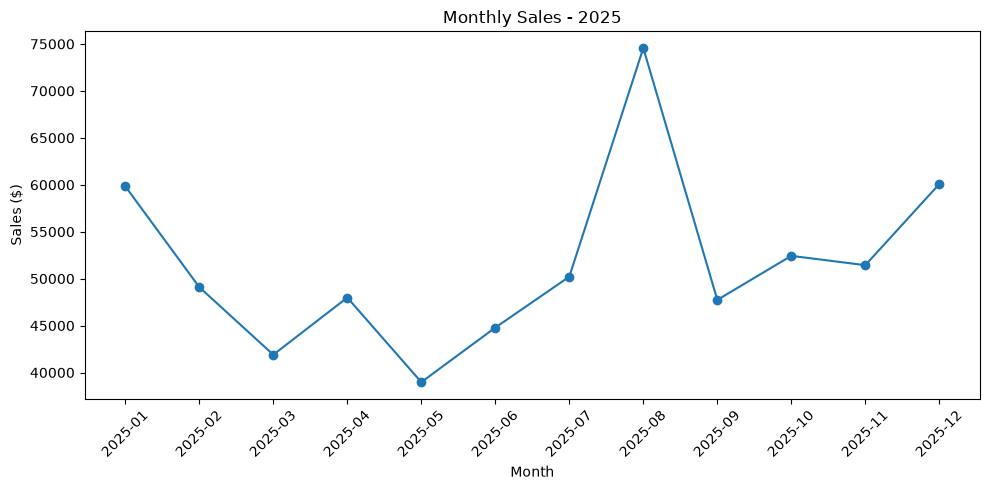

In [108]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["Sales"],
    marker="o"
)

plt.title("Monthly Sales - 2025")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

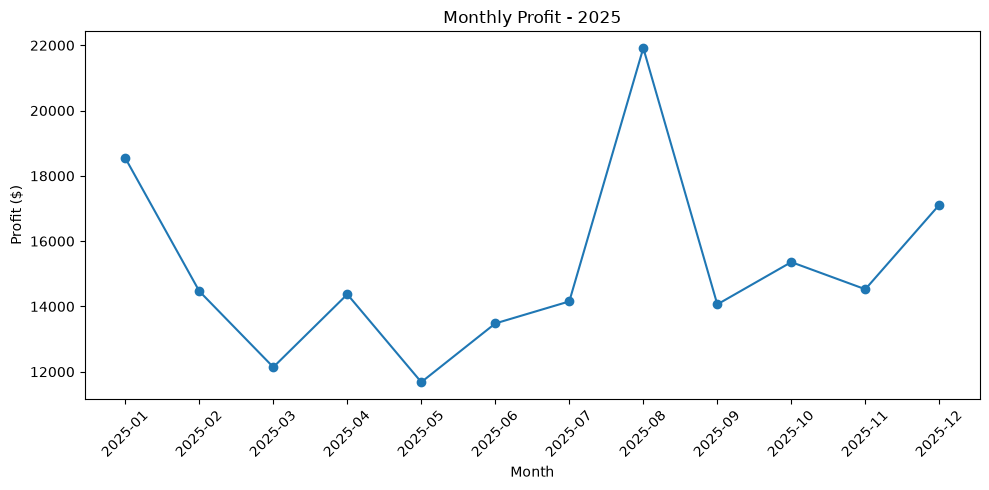

In [109]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["Profit"],
    marker="o"
)

plt.title("Monthly Profit - 2025")
plt.xlabel("Month")
plt.ylabel("Profit ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [114]:
category_sorted = category_summary.sort_values(by="Sales", ascending=False)

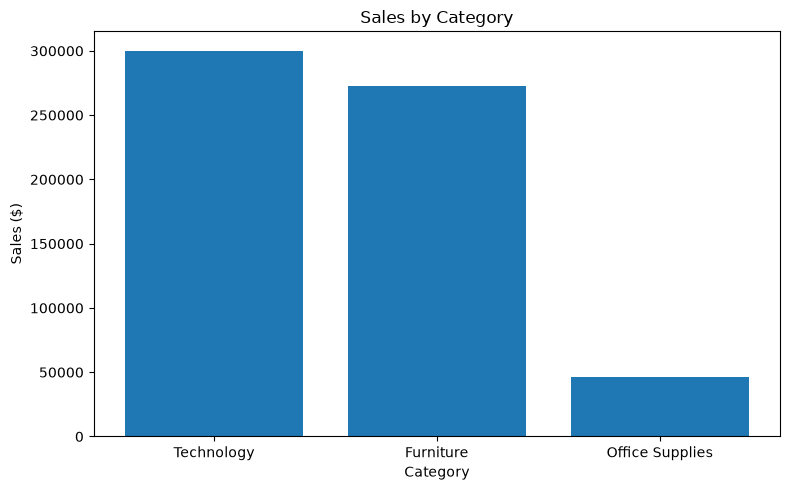

In [127]:
plt.figure(figsize=(8,5))

plt.bar(
    category_sorted.index,
    category_sorted["Sales"]
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")

plt.tight_layout()
plt.show()

In [116]:
lowest_margin_products = product_summary.sort_values(by="Profit_Margin", ascending=True).head(5)

In [117]:
lowest_margin_products

,Sales,Profit,Profit_Margin,Average_Discount
Product,,,,
Filing Cabinet,62321.46,14049.33,22.543326,12.321429
Conference Table,53857.62,12421.73,23.064016,11.442308
Bookcase,46147.02,10783.99,23.368768,9.642857
Office Chair,58586.73,14394.09,24.568857,10.090909
Standing Desk,51747.86,13218.95,25.544921,11.914894


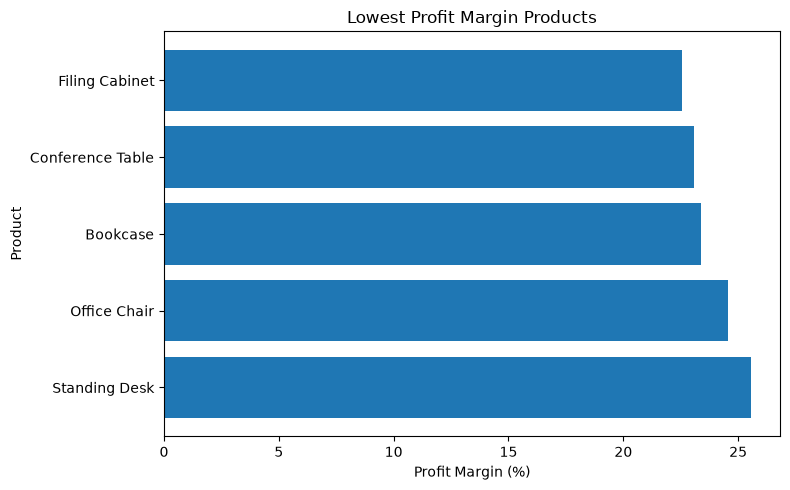

In [119]:
plt.figure(figsize=(8,5))

plt.barh(
    lowest_margin_products.index,
    lowest_margin_products["Profit_Margin"]
)

plt.gca().invert_yaxis()

plt.title("Lowest Profit Margin Products")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

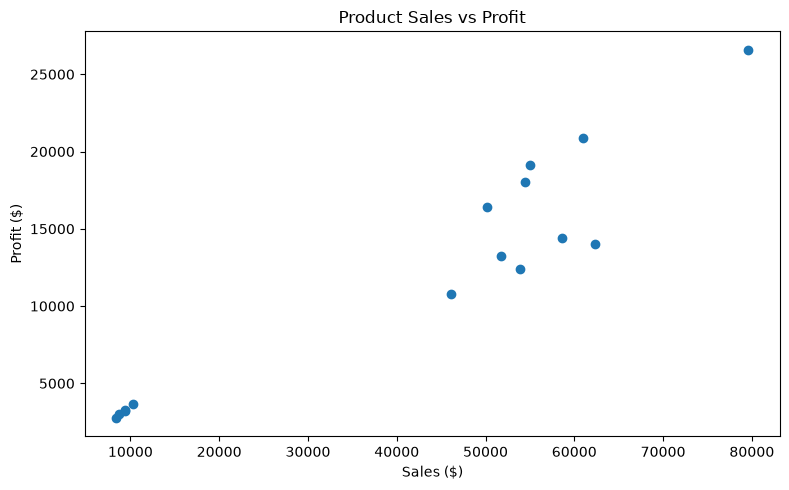

In [122]:
plt.figure(figsize=(8,5))

plt.scatter(
    product_summary["Sales"],
    product_summary["Profit"]
)

plt.title("Product Sales vs Profit")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
#for product in product_summary.index:
#    plt.annotate(
#        product,
#        (
#            product_summary.loc[product, "Sales"],
#            product_summary.loc[product, "Profit"]
#        )
#    )

plt.tight_layout()
plt.show()

## Key Findings

### 1. Overall Business Performance
In 2025, the business generated USD 619K in sales and USD 181.8K in profit across 850 orders, resulting in an overall profit margin of approximately 29.4%.

### 2. Category and Product Performance
Technology was the strongest category by volume, generating the highest sales (USD 300.2K) and profit (USD 101.1K). Office Supplies generated the lowest sales and profit but achieved the highest profit margin at 34.39%. Furniture had the lowest category margin at 23.79%, with Filing Cabinets, Conference Tables, and Bookcases ranking as the three lowest-margin products.

### 3. Customer Segment Performance
Consumer was the largest customer segment, generating USD 338.9K in sales and USD 99.6K in profit. Home Office generated the lowest sales and profit but achieved the highest profit margin at 29.90%, while Corporate had the lowest margin at 29.01%. Overall, profit margins were relatively consistent across all three segments.

### 4. Regional Performance
The South was the strongest region by volume, generating USD 182.0K in sales and USD 53.6K in profit. Central generated the lowest sales and profit but had the highest profit margin at 29.61%. However, regional margins varied by less than one percentage point, indicating relatively consistent profitability across regions.

### 5. Sales Channel Performance
Online was the largest sales channel, generating USD 308.5K in sales and USD 89.4K in profit. Partner generated the lowest sales and profit but achieved the highest profit margin at 29.88%. However, margins across Online, Retail, and Partner differed by less than one percentage point, indicating relatively consistent profitability across sales channels.

### 6. Monthly Performance
August was the strongest month, generating the highest sales (USD 74.6K) and profit (USD 21.9K), while May recorded the lowest sales (USD 39.0K) and profit (USD 11.7K). Sales and profit dropped sharply in September following the August peak. Despite fluctuations in monthly sales volume, profit margins remained relatively stable throughout the year, ranging from approximately 28% to 31%.

### 7. Discount Analysis
Discount levels did not show a clear relationship with profit margins. Margins fluctuated across discount levels rather than consistently declining as discounts increased. At the product level, the correlation between average discount and profit margin was approximately +0.20, indicating only a weak relationship. Therefore, the analysis does not support the conclusion that higher discounts are driving lower profit margins.

### 8. Customer Performance
CUST-0031 Maya Martinez generated the highest total sales and profit, supported by 10 orders. Several customers ranked highly in average order value based on only a single purchase, showing that AOV alone can overstate customer performance. Customers with both high AOV and multiple orders demonstrated more sustained purchasing activity within the dataset.

## Business Recommendations

1. **Investigate Furniture Profitability:**  
   Investigate the factors contributing to Furniture's lower profit margin, particularly for Filing Cabinets, Conference Tables, and Bookcases. Compare product costs, pricing, and other profitability drivers with the higher-margin Technology and Office Supplies categories to identify opportunities for improvement.

2. **Investigate the August Performance Peak:**  
   Investigate the factors behind August's unusually strong sales and profit performance, including product mix, pricing, costs, and potential seasonal factors such as back-to-school or college move-in demand. Identifying the drivers of the August peak could help determine whether similar strategies or timing can be used to improve performance during other periods.

3. **Analyze Repeat and One-Time High-Value Customers:**  
   Analyze repeat high-value customers separately from one-time high-AOV customers to better understand their purchasing behavior. Examine differences in product mix, order timing, pricing, and profitability, and consider incorporating additional customer demographic data to identify characteristics associated with repeat purchasing.

4. **Evaluate Discounts at the Product Level:**  
   Avoid making broad changes to the company's discount strategy based solely on profit margin. The analysis did not show a consistent decline in margins as discount levels increased. Instead, evaluate discounts alongside product-level pricing, costs, sales volume, and profitability to determine where changes may be beneficial.



## Conclusion

Overall, the business remained profitable throughout 2025, generating USD 619K in sales and USD 181.8K in profit with an overall profit margin of approximately 29.4%. Profitability remained relatively consistent across customer segments, regions, sales channels, and months, but the analysis identified opportunities for deeper investigation. In particular, the business should examine the factors contributing to Furniture's lower profit margins and investigate the drivers behind August's strong sales and profit performance. Understanding the differences between weaker and stronger areas of performance could help the company make more informed pricing, product, and sales decisions.

In [124]:
df.to_csv("Customer_Sales_Cleaned.csv", index=False)